# Imports

In [1]:
  !pip install torch==2.7.1+cu126 torchvision==0.22.1+cu126 --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 156.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 144.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 175.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 58.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 78.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 111.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 164.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 133.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 109.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 121.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [2]:
import os
import numpy as np
import random
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import LabelEncoder, label_binarize
import matplotlib.pyplot as plt
import wandb

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Using device: cuda
GPU count: 1
  GPU 0: Tesla P100-PCIE-16GB


# FNO Building blocks

In [3]:
class GridEmbedding2d(nn.Module):
    """Appends normalized (x, y) grid coordinates as 2 extra input channels"""
    def forward(self, x):
        B, _, H, W = x.shape
        grid_y = torch.linspace(0, 1, H, device=x.device).view(1, 1, H, 1).expand(B, 1, H, W)
        grid_x = torch.linspace(0, 1, W, device=x.device).view(1, 1, 1, W).expand(B, 1, H, W)
        return torch.cat([x, grid_x, grid_y], dim=1)


class SpectralConv2d(nn.Module):
    """2D Spectral Convolution with ortho-normalized FFT, Kaiming init,
    learnable bias, and optional spectral dropout."""

    def __init__(self, in_channels, out_channels, modes1, modes2, spectral_dropout=0.0, bias=True):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.spectral_dropout = spectral_dropout

        # Kaiming-like init for complex weights (modern neuraloperator convention)
        std = math.sqrt(2.0 / (in_channels + out_channels))
        self.weights1 = nn.Parameter(
            std * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            std * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat)
        )

        # Learnable bias in spatial domain (after IFFT)
        if bias:
            self.bias = nn.Parameter(torch.zeros(1, out_channels, 1, 1))
        else:
            self.bias = None

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batch_size = x.shape[0]
        x_ft = torch.fft.rfft2(x, norm='ortho')

        out_ft = torch.zeros(
            batch_size, self.out_channels, x.size(-2), x.size(-1) // 2 + 1,
            dtype=torch.cfloat, device=x.device
        )

        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, :self.modes1, :self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1:, :self.modes2], self.weights2
        )

        # Spectral dropout: randomly zero out Fourier modes during training
        if self.training and self.spectral_dropout > 0:
            mask = (torch.rand(1, 1, out_ft.size(-2), out_ft.size(-1),
                    device=out_ft.device) > self.spectral_dropout).float()
            out_ft = out_ft * mask

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)), norm='ortho')

        if self.bias is not None:
            x = x + self.bias

        return x


class ChannelMLP(nn.Module):
    """2-layer channel mixing MLP"""

    def __init__(self, channels, expansion=0.5, dropout=0.0):
        super().__init__()
        hidden = int(channels * expansion)
        self.fc1 = nn.Conv2d(channels, hidden, kernel_size=1)
        self.fc2 = nn.Conv2d(hidden, channels, kernel_size=1)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class FNOImprovedBlock2d(nn.Module):
    """FNO block: spectral conv + skip → norm → activation → channel MLP + skip → norm → activation"""

    def __init__(self, channels, modes1, modes2, activation='gelu',
                 dropout=0.1, dropout_mode='both', norm='batch',
                 mlp_expansion=0.5, use_channel_mlp=True):
        super().__init__()
        use_spectral = dropout_mode in ('spectral', 'both')
        use_spatial = dropout_mode in ('spatial', 'both')

        self.spectral_conv = SpectralConv2d(
            channels, channels, modes1, modes2,
            spectral_dropout=dropout if use_spectral else 0.0
        )
        self.linear = nn.Conv2d(channels, channels, kernel_size=1)

        def make_norm(channels):
            if norm == 'batch':
                return nn.BatchNorm2d(channels)
            elif norm == 'instance':
                return nn.InstanceNorm2d(channels)
            elif norm == 'group':
                return nn.GroupNorm(num_groups=min(8, channels), num_channels=channels)
            else:
                return nn.Identity()

        self.norm1 = make_norm(channels)
        self.norm2 = make_norm(channels)

        self.activation = nn.GELU() if activation == 'gelu' else nn.ReLU()
        self.dropout = nn.Dropout2d(dropout) if use_spatial else nn.Identity()

        # Channel MLP for nonlinear channel mixing
        if use_channel_mlp:
            self.channel_mlp = ChannelMLP(channels, expansion=mlp_expansion, dropout=dropout)
        else:
            self.channel_mlp = None

    def forward(self, x):
        residual = x
        h = self.spectral_conv(x) + self.linear(x)
        h = self.activation(self.norm1(h))
        h = self.dropout(h)
        if self.channel_mlp is not None:
            h = h + self.channel_mlp(h)
            h = self.activation(self.norm2(h))
        return h + residual


class LiftingLayer(nn.Module):
    """Projects input to latent space via 2-layer MLP with expansion"""

    def __init__(self, in_channels, hidden_channels, expansion=2):
        super().__init__()
        mid = int(hidden_channels * expansion)
        self.fc1 = nn.Conv2d(in_channels, mid, kernel_size=1)
        self.activation = nn.GELU()
        self.fc2 = nn.Conv2d(mid, hidden_channels, kernel_size=1)

    def forward(self, x):
        return self.fc2(self.activation(self.fc1(x)))


class ProjectionLayer(nn.Module):
    """Projects from latent space to class logits via 1x1 convs + global pooling."""

    def __init__(self, hidden_channels, out_channels, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Conv2d(hidden_channels, hidden_channels // 2, kernel_size=1)
        self.norm = nn.InstanceNorm2d(hidden_channels // 2)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Conv2d(hidden_channels // 2, out_channels, kernel_size=1)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = F.gelu(self.norm(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return x



class NaiveSpectralConv2d(nn.Module):
    """Normal 2D Spectral Convolution"""

    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat)
        )
        self.weights2 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat)
        )

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batch_size = x.shape[0]
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(
            batch_size, self.out_channels, x.size(-2), x.size(-1) // 2 + 1,
            dtype=torch.cfloat, device=x.device
        )

        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, :self.modes1, :self.modes2], self.weights1
        )
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1:, :self.modes2], self.weights2
        )

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x


class NaiveFNOBlock2d(nn.Module):
    """Single FNO block: spectral conv (global) + 1x1 conv (local) + norm + activation + dropout."""

    def __init__(self, channels, modes1, modes2, activation='gelu', dropout=0.1):
        super().__init__()
        self.spectral_conv = NaiveSpectralConv2d(channels, channels, modes1, modes2)
        self.linear = nn.Conv2d(channels, channels, kernel_size=1)
        self.norm = nn.InstanceNorm2d(channels)
        self.activation = nn.GELU() if activation == 'gelu' else nn.ReLU()
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = self.norm(self.spectral_conv(x) + self.linear(x))
        x = self.activation(x)
        x = self.dropout(x)
        return x


class NaiveLiftingLayer(nn.Module):
    """Projects input from physical space to higher-dimensional latent space."""

    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.fc = nn.Conv2d(in_channels, hidden_channels, kernel_size=1)

    def forward(self, x):
        return self.fc(x)


class NaiveProjectionLayer(nn.Module):
    """Projects from latent space to class logits via 1x1 convs + global pooling."""

    def __init__(self, hidden_channels, out_channels, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Conv2d(hidden_channels, hidden_channels // 2, kernel_size=1)
        self.norm = nn.InstanceNorm2d(hidden_channels // 2)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Conv2d(hidden_channels // 2, out_channels, kernel_size=1)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = F.gelu(self.norm(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return x


class NaiveFNO(nn.Module):
    """Fourier Neural Operator for Image Classification"""

    def __init__(self, in_channels=1, num_classes=3, hidden_channels=64,
                 modes1=12, modes2=12, num_layers=6, activation='gelu', dropout=0.1):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        self.hidden_channels = hidden_channels

        self.lifting = NaiveLiftingLayer(in_channels, hidden_channels)
        self.fno_blocks = nn.ModuleList([
            NaiveFNOBlock2d(hidden_channels, modes1, modes2, activation, dropout)
            for _ in range(num_layers)
        ])
        self.projection = NaiveProjectionLayer(hidden_channels, num_classes, dropout)

    def forward(self, x):
        x = self.lifting(x)
        for block in self.fno_blocks:
            x = block(x)
        x = self.projection(x)
        return x


class HourglassFNO(nn.Module):
    """Hourglass FNO with varying modes, constant channels.
    
    Architecture (6 layers, base_modes=12):
        Encoder:  12 -> 9 -> 6   (modes decrease)
        Decoder:  6 -> 9 -> 12   (modes increase)
    """

    def __init__(self, in_channels=1, num_classes=3, hidden_channels=64,
                 base_modes=12, num_layers=6, activation='gelu',
                 dropout=0.1, dropout_mode='both', norm='batch',
                 mlp_expansion=0.5, use_channel_mlp=True,
                 mode_reduction_factor=0.75):
        super().__init__()
        assert num_layers % 2 == 0, "num_layers must be even for symmetric hourglass"
        
        self.hidden_channels = hidden_channels
        self.base_modes = base_modes
        self.num_layers = num_layers
        self.dropout_mode = dropout_mode
        
        half_layers = num_layers // 2
        self.encoder_modes = []
        for i in range(half_layers):
            m = max(4, int(base_modes * (mode_reduction_factor ** i)))
            self.encoder_modes.append(m)
        self.decoder_modes = list(reversed(self.encoder_modes))
        
        # Grid embedding + Lifting
        self.grid = GridEmbedding2d()
        self.lifting = LiftingLayer(in_channels + 2, hidden_channels)
        
        # Encoder blocks
        self.encoder_blocks = nn.ModuleList([
            FNOImprovedBlock2d(hidden_channels, self.encoder_modes[i], self.encoder_modes[i],
                       activation, dropout, dropout_mode, norm, mlp_expansion, use_channel_mlp)
            for i in range(half_layers)
        ])
        
        # Decoder blocks
        self.decoder_blocks = nn.ModuleList([
            FNOImprovedBlock2d(hidden_channels, self.decoder_modes[i], self.decoder_modes[i],
                       activation, dropout, dropout_mode, norm, mlp_expansion, use_channel_mlp)
            for i in range(half_layers)
        ])
        
        # Learnable skip connection scaling
        self.skip_scales = nn.ParameterList([
            nn.Parameter(torch.ones(1) * 0.1) for _ in range(half_layers)
        ])
        
        # Projection head
        self.projection = ProjectionLayer(hidden_channels, num_classes, dropout)
        
    def forward(self, x):
        x = self.grid(x)
        x = self.lifting(x)
        
        # Encoder - store outputs for skip connections
        encoder_outputs = []
        for block in self.encoder_blocks:
            encoder_outputs.append(x)
            x = block(x)
        
        # Decoder with additive skip connections
        for i, block in enumerate(self.decoder_blocks):
            x = block(x)
            # Add scaled skip connection from corresponding encoder layer
            skip_idx = len(encoder_outputs) - i - 1
            if skip_idx >= 0:
                x = x + self.skip_scales[i] * encoder_outputs[skip_idx]
        
        x = self.projection(x)
        return x

class FNO_CE(nn.Module):
    """FNO_CE for Image Classification """

    def __init__(self, in_channels=1, num_classes=3, hidden_channels=128,
                 modes=20, num_layers=6, activation='gelu',
                 dropout=0.1, dropout_mode='both', norm='batch',
                 mlp_expansion=0.5, use_channel_mlp=True):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.modes = modes
        self.num_layers = num_layers
        self.dropout_mode = dropout_mode

        self.grid = GridEmbedding2d()
        self.lifting = LiftingLayer(in_channels + 2, hidden_channels)
        self.fno_blocks = nn.ModuleList([
            FNOImprovedBlock2d(hidden_channels, modes, modes, activation,
                       dropout, dropout_mode, norm,
                       mlp_expansion, use_channel_mlp)
            for _ in range(num_layers)
        ])
        self.projection = ProjectionLayer(hidden_channels, num_classes, dropout)

    def forward(self, x):
        x = self.grid(x)
        x = self.lifting(x)
        for block in self.fno_blocks:
            x = block(x)
        x = self.projection(x)
        return x

In [4]:
batch_size = 32
size = 150

config = {
    "in_channels": 1,
    "num_classes": 3,
    "hidden_channels": 64,
    "modes":12,
    "num_layers": 6,
    "activation": "gelu",
    "dropout": 0.1,
    "dropout_mode":"none",
    "norm":"batch",
    "batch_size": batch_size,
    "image_size": size
}

In [5]:
fno_ce_light = FNO_CE(
    in_channels=config["in_channels"],
    num_classes=config["num_classes"],
    hidden_channels=config["hidden_channels"],
    modes=config["modes"],
    num_layers=config["num_layers"],
    activation=config["activation"],
    dropout=config["dropout"],
    dropout_mode=config["dropout_mode"],
    norm=config["norm"]
)

fno_ce = FNO_CE(
    in_channels=config["in_channels"],
    num_classes=config["num_classes"],
    hidden_channels=config["hidden_channels"],
    modes=14,
    num_layers=config["num_layers"],
    activation=config["activation"],
    dropout=config["dropout"],
    dropout_mode=config["dropout_mode"],
    norm=config["norm"]
)

fno_hourglass = HourglassFNO(
    in_channels=config["in_channels"],
    num_classes=config["num_classes"],
    hidden_channels=config["hidden_channels"],
    base_modes=config["modes"],
    num_layers=config["num_layers"],
    activation=config["activation"],
    dropout=config["dropout"],
    dropout_mode=config["dropout_mode"],
    norm=config["norm"]
)

# Naive FNO: matching FNOImageClassifier from reference implementation
naive_fno = NaiveFNO(
    in_channels=config["in_channels"],
    num_classes=config["num_classes"],
    hidden_channels=64,
    modes1=config["modes"],
    modes2=config["modes"],
    num_layers=6,
    activation=config["activation"],
    dropout=config["dropout"]
)

for model in [fno_ce, fno_ce_light, fno_hourglass, naive_fno]:
    total_params = sum(p.numel() for p in model.parameters())
    print(f"{model.__class__.__name__}: {total_params:,} params")

FNO_CE: 9,696,771 params
FNO_CE: 7,140,867 params
HourglassFNO: 4,339,206 params
NaiveFNO: 7,105,155 params


# Dataloader

In [6]:
class CustomDataset(Dataset):
    """Lazy-loading dataset for .npy gravitational lensing images"""

    def __init__(self, folder_path, transforms=None, max_samples=None):
        self.folder_path = folder_path
        self.transform = transforms
        self.class_folders = sorted(
            [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]
        )

        self.label_encoder = LabelEncoder()
        self.label_encoder.fit(self.class_folders)

        # Store (file_path, class_name) pairs — lazy loading
        self.samples = []
        for class_folder in self.class_folders:
            class_path = os.path.join(folder_path, class_folder)
            files = sorted([f for f in os.listdir(class_path) if f.endswith('.npy')])
            if max_samples is not None:
                files = files[:max_samples]
            for file_name in files:
                self.samples.append((os.path.join(class_path, file_name), class_folder))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, class_name = self.samples[idx]
        data_point = np.load(file_path)
        label = self.label_encoder.transform([class_name])[0]

        # Z-score normalization per channel
        mean = np.mean(data_point, axis=(1, 2), keepdims=True)
        std = np.std(data_point, axis=(1, 2), keepdims=True)
        data_point = (data_point - mean) / (std + 1e-8)

        data_point = torch.from_numpy(data_point).float()

        if self.transform:
            data_point = self.transform(data_point)

        return data_point, torch.tensor(label, dtype=torch.long)

folder_path = '/kaggle/input/datasets/mldtype/gravitational-lens-img/dataset/train'
folder_path_val = '/kaggle/input/datasets/mldtype/gravitational-lens-img/dataset/val'

size = 150
batch_size = 32


train_augmentation = transforms.Compose([
    transforms.Resize(size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomApply([transforms.RandomRotation(180)], p=0.5),
])

# Val/test — resize only, no augmentation
eval_augmentation = transforms.Compose([transforms.Resize(size)])
custom_dataset = CustomDataset(folder_path, transforms=train_augmentation)
train_size = int(0.9 * len(custom_dataset))
test_size = len(custom_dataset) - train_size
train_dataset, test_dataset = random_split(custom_dataset, [train_size, test_size])

# Override transform for test subset — no augmentation at eval time
# We need a separate dataset instance for clean test evaluation
custom_dataset_test = CustomDataset(folder_path, transforms=eval_augmentation)
_, test_dataset = random_split(custom_dataset_test, [train_size, test_size],
                               generator=torch.Generator().manual_seed(SEED))

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Validation (separate folder)
custom_dataset_val = CustomDataset(folder_path_val, transforms=eval_augmentation)
val_dataloader = DataLoader(custom_dataset_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Store class names for per-class metrics
class_names = list(custom_dataset.label_encoder.classes_)

In [7]:
def evaluate(model, dataloader, criterion, device):
    """Evaluate model on a dataloader. Returns loss, accuracy, all preds, all labels, all probs."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

criterion = nn.CrossEntropyLoss()

In [8]:
# Train eval dataloader (no augmentation for evaluation)
custom_dataset_train_eval = CustomDataset(folder_path, transforms=eval_augmentation)
train_eval_dataset, _ = random_split(custom_dataset_train_eval, [train_size, test_size],
                                      generator=torch.Generator().manual_seed(SEED))
train_eval_dataloader = DataLoader(train_eval_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train eval samples: {len(train_eval_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Held out Val samples: {len(custom_dataset_val)}")

Train eval samples: 27000
Test samples: 3000
Held out Val samples: 7500


# Training

In [9]:
MODELS = {
      "naive_fno": naive_fno,                                                                   
      "fno_v2": fno_ce_light,       # modes=12
      "fno_v2_large": fno_ce,       # modes=14                                                  
      "fno_hourglass": fno_hourglass,                                                           
  } 

SELECTED_MODEL = "naive_fno" 

train_config = {
    # Model
    "model_name": SELECTED_MODEL,
    "model_overrides": {},  # Override any model config params here
    "lr": 9e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "batch_size": batch_size,
    "scheduler": "step",  # "step" or "cosine"
    "scheduler_step_size": 10,
    "scheduler_gamma": 0.75,
    "save_dir": "/kaggle/working/checkpoints",
    "top_k_checkpoints": 2,
    "detailed_metrics_every": 5,
    "loss": "crossentropy",
    
    # Wandb
    "wandb_project": "fno-gravitational-lensing",
    "wandb_enabled": True,
}



In [10]:
model = MODELS[train_config["model_name"]]
model = model.to(device)

# Loss function
if train_config["loss"] == "focal":
    criterion = FocalLoss(gamma=2)
else:
    criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(), 
    lr=train_config["lr"], 
    weight_decay=train_config["weight_decay"]
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=train_config["scheduler_step_size"],
    gamma=train_config["scheduler_gamma"]
)

# Wandb init
if train_config["wandb_enabled"]:
    wandb.init(project=train_config["wandb_project"], config=train_config)
    wandb.watch(model, log="all", log_freq=50)

# Checkpoint directory
save_dir = train_config["save_dir"]
os.makedirs(save_dir, exist_ok=True)

top_k = train_config["top_k_checkpoints"]
top_checkpoints = []

print(f"\nStarting training: {train_config['model_name']}")
print(f"Device: {device}")
print("=" * 60)

for epoch in range(train_config["num_epochs"]):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # Step scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # --- Evaluate ---
    test_loss, test_acc, test_preds, test_labels, _ = evaluate(model, test_dataloader, criterion, device)
    val_loss, val_acc, val_preds, val_labels, _ = evaluate(model, val_dataloader, criterion, device)

    # Compute F1
    val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)
    test_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)

    # Log dict
    log_dict = {
        "epoch": epoch + 1,
        "train/loss": train_loss,
        "train/accuracy": train_acc,
        "test/loss": test_loss,
        "test/accuracy": test_acc,
        "test/f1_macro": test_f1,
        "val/loss": val_loss,
        "val/accuracy": val_acc,
        "val/f1_macro": val_f1,
        "lr": current_lr,
    }

    # --- Top-K checkpoint management ---
    min_f1 = top_checkpoints[-1][0] if len(top_checkpoints) == top_k else -1.0
    if val_f1 > min_f1:
        ckpt_path = os.path.join(save_dir, f"{train_config['model_name']}_epoch{epoch+1}_f1{val_f1:.4f}.pth")
        torch.save(model.state_dict(), ckpt_path)

        top_checkpoints.append((val_f1, epoch + 1, ckpt_path))
        top_checkpoints.sort(key=lambda x: x[0], reverse=True)

        if len(top_checkpoints) > top_k:
            _, removed_epoch, removed_path = top_checkpoints.pop()
            if os.path.exists(removed_path):
                os.remove(removed_path)
            print(f"  [Removed] Epoch {removed_epoch} checkpoint (no longer top-{top_k})")

        print(f"  [Checkpoint] Epoch {epoch+1}: val F1 = {val_f1:.4f}")
        print(f"  [Top-{top_k}] " + " | ".join(f"E{e}: F1={f:.4f}" for f, e, _ in top_checkpoints))

        # Save as wandb artifact
        if train_config["wandb_enabled"]:
            artifact = wandb.Artifact(f"{train_config['model_name']}-best", type="model",
                                      metadata={"val_f1": val_f1, "epoch": epoch + 1})
            artifact.add_file(ckpt_path)
            wandb.log_artifact(artifact)


    if (epoch + 1) % train_config["detailed_metrics_every"] == 0:
        for split, preds, labels_arr in [("test", test_preds, test_labels), ("val", val_preds, val_labels)]:
            prec = precision_score(labels_arr, preds, average="macro", zero_division=0)
            rec = recall_score(labels_arr, preds, average="macro", zero_division=0)
            log_dict[f"{split}/precision_macro"] = prec
            log_dict[f"{split}/recall_macro"] = rec

            f1_per = f1_score(labels_arr, preds, average=None, zero_division=0)
            prec_per = precision_score(labels_arr, preds, average=None, zero_division=0)
            rec_per = recall_score(labels_arr, preds, average=None, zero_division=0)
            for i, cname in enumerate(class_names):
                log_dict[f"{split}/f1_{cname}"] = f1_per[i]
                log_dict[f"{split}/precision_{cname}"] = prec_per[i]
                log_dict[f"{split}/recall_{cname}"] = rec_per[i]

        # Print per-class breakdown
        val_f1_per = f1_score(val_labels, val_preds, average=None, zero_division=0)
        val_prec_per = precision_score(val_labels, val_preds, average=None, zero_division=0)
        val_rec_per = recall_score(val_labels, val_preds, average=None, zero_division=0)
        print(f"  Per-class (val):")
        for i, cname in enumerate(class_names):
            print(f"    {cname}: F1={val_f1_per[i]:.4f}  P={val_prec_per[i]:.4f}  R={val_rec_per[i]:.4f}")

    if train_config["wandb_enabled"]:
        wandb.log(log_dict)

    print(f"Epoch {epoch+1}/{train_config['num_epochs']} | LR: {current_lr:.2e} | "
          f"Train: {train_acc:.4f} | Test: {test_acc:.4f} F1: {test_f1:.4f} | "
          f"Val: {val_acc:.4f} F1: {val_f1:.4f}")

# Training complete
if top_checkpoints:
    best_f1, best_epoch, best_path = top_checkpoints[0]
    print(f"\n{'='*60}")
    print(f"Training complete. Best val F1: {best_f1:.4f} (epoch {best_epoch})")
    print(f"Top-{top_k} checkpoints:")
    for f1, ep, path in top_checkpoints:
        print(f"  Epoch {ep}: F1={f1:.4f} -> {path}")

if train_config["wandb_enabled"]:
    wandb.finish()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: snehanshumukh (snehanshumukh-na) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



Starting training: naive_fno
Device: cuda


/usr/local/lib/python3.12/dist-packages/wandb/integration/torch/wandb_torch.py:206: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:307.)
  flat = flat.type(torch.FloatTensor)


  [Checkpoint] Epoch 1: val F1 = 0.1667
  [Top-2] E1: F1=0.1667
Epoch 1/200 | LR: 9.00e-04 | Train: 0.3363 | Test: 0.3363 F1: 0.1678 | Val: 0.3333 F1: 0.1667


KeyboardInterrupt: 

# Metric Calculation Helper

In [11]:
def compute_metrics(preds, labels, class_names):
    """Compute overall and per-class metrics."""
    metrics = {}
    
    # Overall metrics
    metrics['accuracy'] = accuracy_score(labels, preds)
    metrics['precision_macro'] = precision_score(labels, preds, average='macro', zero_division=0)
    metrics['recall_macro'] = recall_score(labels, preds, average='macro', zero_division=0)
    metrics['f1_macro'] = f1_score(labels, preds, average='macro', zero_division=0)
    
    # Per-class metrics
    precision_per = precision_score(labels, preds, average=None, zero_division=0)
    recall_per = recall_score(labels, preds, average=None, zero_division=0)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    
    for i, cname in enumerate(class_names):
        metrics[f'precision_{cname}'] = precision_per[i]
        metrics[f'recall_{cname}'] = recall_per[i]
        metrics[f'f1_{cname}'] = f1_per[i]
    
    return metrics


def compute_roc_auc(labels, probs, class_names):
    """Compute ROC curves and AUC scores for multiclass classification.

    Returns per-class AUC plus macro and micro averages.
    """
    num_classes = len(class_names)
    labels_bin = label_binarize(labels, classes=list(range(num_classes)))

    fpr = {}
    tpr = {}
    roc_auc = {}

    # Per-class ROC/AUC
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average: aggregate all classes
    fpr["micro"], tpr["micro"], _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Macro-average: mean of per-class AUCs
    roc_auc["macro"] = np.mean([roc_auc[i] for i in range(num_classes)])

    return fpr, tpr, roc_auc


def plot_roc_curves(fpr, tpr, roc_auc, class_names, title="ROC Curves"):
    """Plot ROC curves for all classes plus micro-average."""
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    for i, cname in enumerate(class_names):
        plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)], lw=2,
                 label=f'{cname} (AUC = {roc_auc[i]:.4f})')
    
    # Plot micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"], color='black', lw=2, linestyle='--',
             label=f'Micro-avg (AUC = {roc_auc["micro"]:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k:', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()


def print_metrics(metrics, split_name, class_names):
    """Pretty print metrics."""
    print(f"\n{'='*50}")
    print(f"{split_name} Metrics")
    print(f"{'='*50}")
    print(f"Overall Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Macro Precision:   {metrics['precision_macro']:.4f}")
    print(f"Macro Recall:      {metrics['recall_macro']:.4f}")
    print(f"Macro F1:          {metrics['f1_macro']:.4f}")
    print(f"\nPer-class metrics:")
    print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1':<12}")
    print("-" * 51)
    for cname in class_names:
        print(f"{cname:<15} {metrics[f'precision_{cname}']:<12.4f} {metrics[f'recall_{cname}']:<12.4f} {metrics[f'f1_{cname}']:<12.4f}")

def plot_confusion_matrices(results, class_names):
    """Plot confusion matrices for multiple models."""
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4.5))
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, (_, acc, preds, labels, _)) in zip(axes, results.items()):
        cm = confusion_matrix(labels, preds)
        n_classes = len(class_names)

        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.set_title(f"{model_name}\n(acc={acc:.3f})", fontsize=10)
        ax.set_xticks(range(n_classes))
        ax.set_yticks(range(n_classes))
        ax.set_xticklabels(class_names, fontsize=9)
        ax.set_yticklabels(class_names, fontsize=9)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        for i in range(n_classes):
            row_total = cm[i].sum()
            for j in range(n_classes):
                pct = cm[i, j] / row_total * 100 if row_total > 0 else 0
                color = "white" if cm[i, j] > cm.max() / 2 else "black"
                ax.text(j, i, f"{cm[i,j]}\n({pct:.1f}%)",
                        ha="center", va="center", color=color, fontsize=8)

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Evaluation

In [12]:
# Load model weights - UPDATE THESE PATHS
fno_ce_light.load_state_dict(torch.load("/kaggle/input/datasets/mldtype/fno-weights/weights/fno_ce_light_f1_9555.pth", map_location=device))
fno_ce.load_state_dict(torch.load("/kaggle/input/datasets/mldtype/fno-weights/weights/fno_ce_f1_9338.pth", map_location=device))
fno_hourglass.load_state_dict(torch.load("/kaggle/input/datasets/mldtype/fno-weights/weights/fno_hourglas_f1_9408.pth", map_location=device))
naive_fno.load_state_dict(torch.load("/kaggle/input/datasets/mldtype/fno-weights/weights/naive_fno_f1_7259.pth", map_location=device))

# Move models to device
fno_ce_light = fno_ce_light.to(device)
fno_ce = fno_ce.to(device)
fno_hourglass = fno_hourglass.to(device)
naive_fno = naive_fno.to(device)

models = {
    "FNO-CE-Light": fno_ce_light,
    "FNO-CE": fno_ce,
    "FNO-Hourglass": fno_hourglass,
    "Naive-FNO": naive_fno
}
print("Models loaded and moved to device.")

Models loaded and moved to device.


## Evaluate on Val Set


############################################################
# FNO-CE-Light
############################################################

VALIDATION Metrics
Overall Accuracy:  0.9557
Macro Precision:   0.9557
Macro Recall:      0.9557
Macro F1:          0.9555

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9544       0.9868       0.9703      
sphere          0.9548       0.9212       0.9377      
vort            0.9581       0.9592       0.9586      

Validation AUC scores:
  Macro AUC: 0.9945
  Micro AUC: 0.9954
  Per-class:
    no: 0.9972
    sphere: 0.9901
    vort: 0.9960


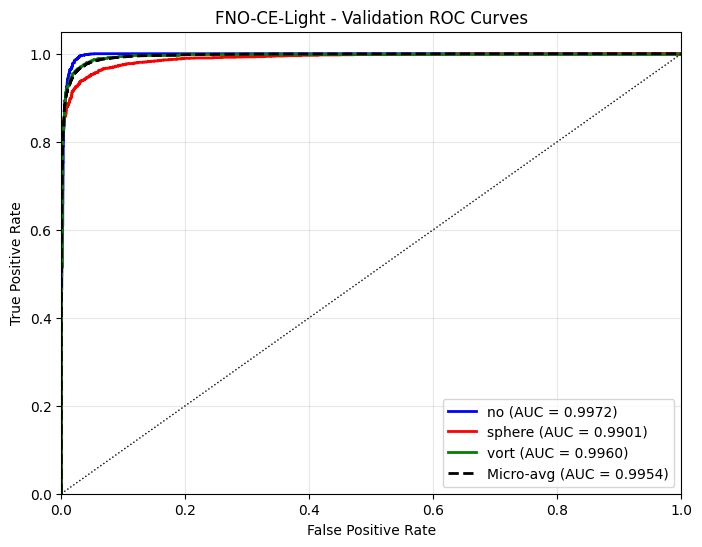


############################################################
# FNO-CE
############################################################

VALIDATION Metrics
Overall Accuracy:  0.9343
Macro Precision:   0.9341
Macro Recall:      0.9343
Macro F1:          0.9338

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9410       0.9832       0.9617      
sphere          0.9294       0.8852       0.9068      
vort            0.9318       0.9344       0.9331      

Validation AUC scores:
  Macro AUC: 0.9891
  Micro AUC: 0.9909
  Per-class:
    no: 0.9954
    sphere: 0.9808
    vort: 0.9912


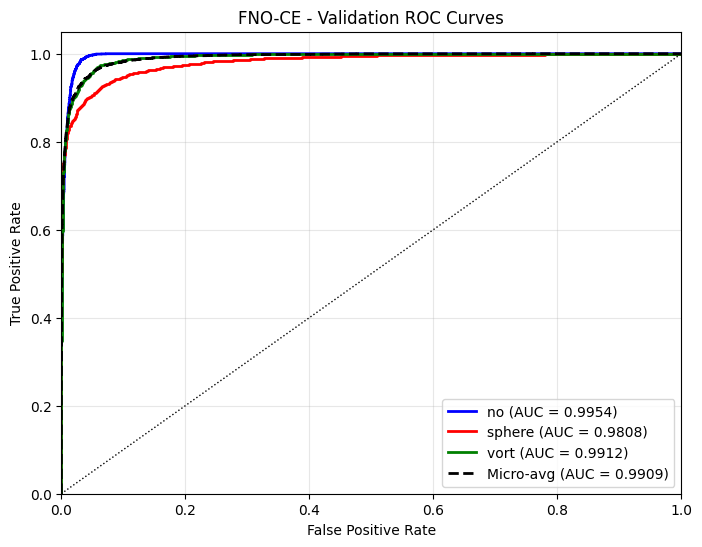


############################################################
# FNO-Hourglass
############################################################

VALIDATION Metrics
Overall Accuracy:  0.9412
Macro Precision:   0.9413
Macro Recall:      0.9412
Macro F1:          0.9408

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9383       0.9856       0.9614      
sphere          0.9457       0.8924       0.9183      
vort            0.9400       0.9456       0.9428      

Validation AUC scores:
  Macro AUC: 0.9904
  Micro AUC: 0.9918
  Per-class:
    no: 0.9957
    sphere: 0.9830
    vort: 0.9925


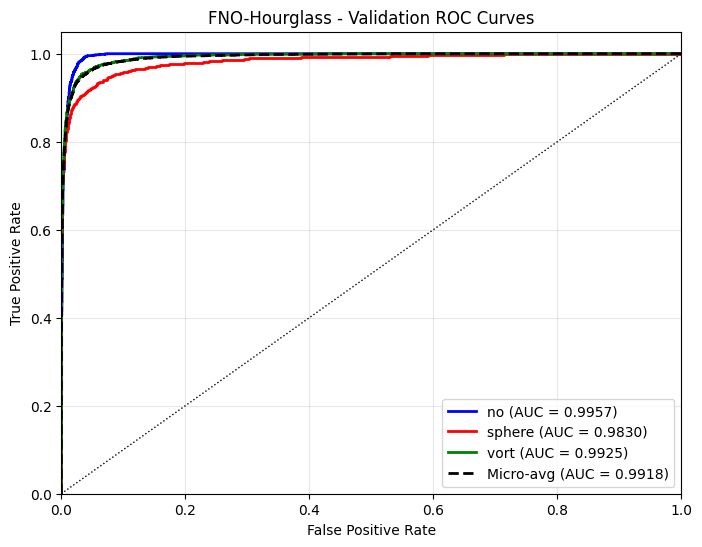


############################################################
# Naive-FNO
############################################################

VALIDATION Metrics
Overall Accuracy:  0.7360
Macro Precision:   0.7302
Macro Recall:      0.7360
Macro F1:          0.7259

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.7699       0.9608       0.8548      
sphere          0.6985       0.5328       0.6045      
vort            0.7222       0.7144       0.7183      

Validation AUC scores:
  Macro AUC: 0.8945
  Micro AUC: 0.9019
  Per-class:
    no: 0.9666
    sphere: 0.8276
    vort: 0.8893


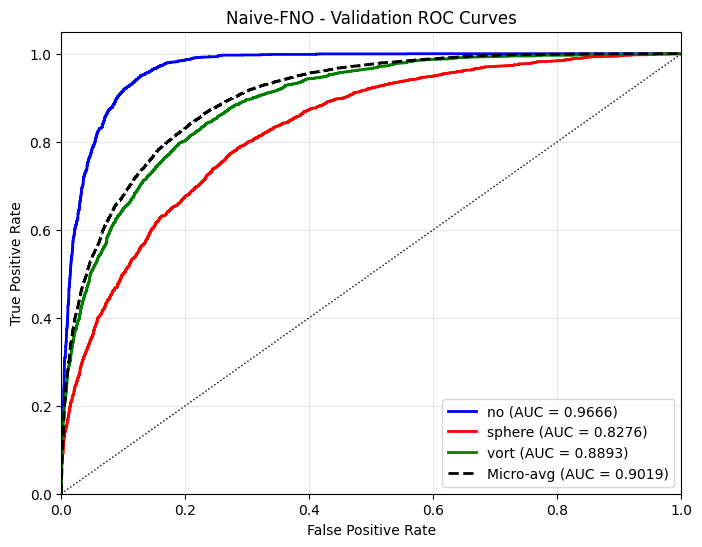

In [14]:
# Evaluate on Validation set (separate cell as requested)
all_val_results={}
for model_name, model in models.items():
    print(f"\n{'#'*60}")
    print(f"# {model_name}")
    print(f"{'#'*60}")
    
    # Validation evaluation
    val_loss, val_acc, val_preds, val_labels, val_probs = evaluate(model, val_dataloader, criterion, device)
    all_val_results[model_name] = (val_loss, val_acc, val_preds, val_labels, val_probs)
    val_metrics = compute_metrics(val_preds, val_labels, class_names)
    print_metrics(val_metrics, "VALIDATION", class_names)
    
    # ROC-AUC for validation
    fpr, tpr, roc_auc = compute_roc_auc(val_labels, val_probs, class_names)
    print(f"\nValidation AUC scores:")
    print(f"  Macro AUC: {roc_auc['macro']:.4f}")
    print(f"  Micro AUC: {roc_auc['micro']:.4f}")
    print(f"  Per-class:")
    for i, cname in enumerate(class_names):
        print(f"    {cname}: {roc_auc[i]:.4f}")
    plot_roc_curves(fpr, tpr, roc_auc, class_names, title=f"{model_name} - Validation ROC Curves")

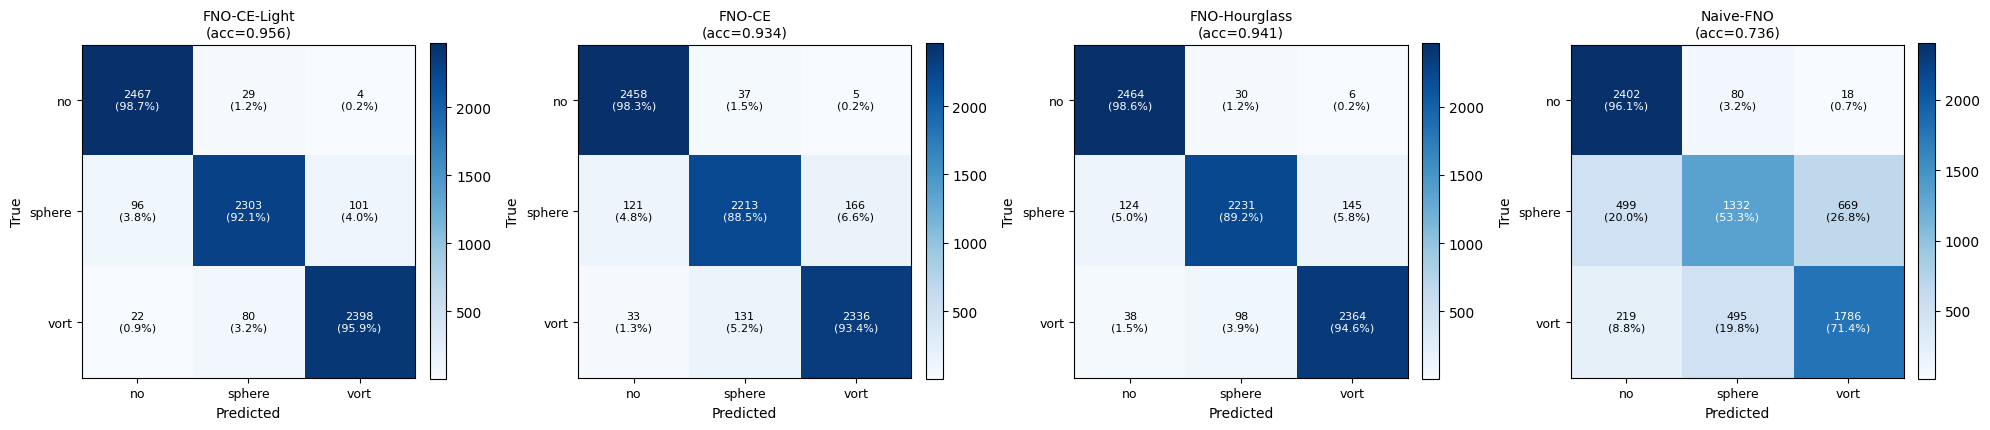

In [15]:
if all_val_results:
    plot_confusion_matrices(all_val_results, class_names)

## Evaluate on Train and Test set


############################################################
# FNO-CE-Light
############################################################

TRAIN Metrics
Overall Accuracy:  0.9946
Macro Precision:   0.9946
Macro Recall:      0.9945
Macro F1:          0.9945

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9925       0.9987       0.9956      
sphere          0.9946       0.9905       0.9925      
vort            0.9966       0.9945       0.9955      

Train AUC scores:
  Macro AUC: 0.9996
  Micro AUC: 0.9997
  Per-class:
    no: 0.9998
    sphere: 0.9994
    vort: 0.9998


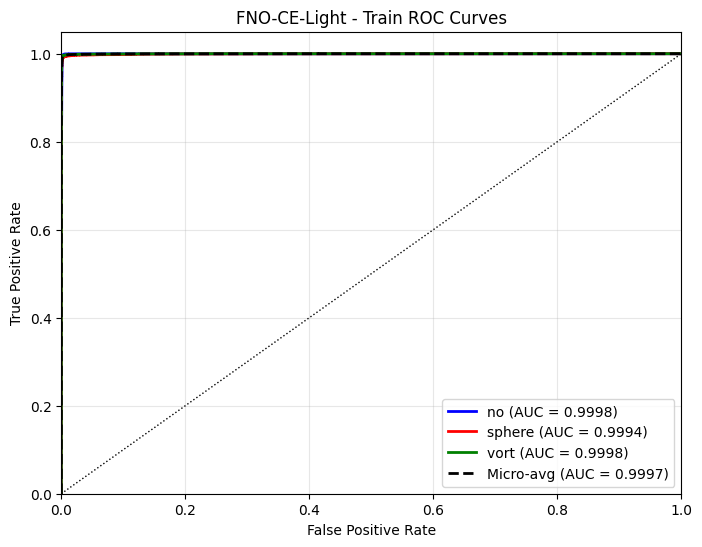


TEST Metrics
Overall Accuracy:  0.9927
Macro Precision:   0.9927
Macro Recall:      0.9928
Macro F1:          0.9928

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9911       0.9960       0.9936      
sphere          0.9924       0.9868       0.9896      
vort            0.9946       0.9957       0.9952      

Test AUC scores:
  Macro AUC: 0.9995
  Micro AUC: 0.9997
  Per-class:
    no: 0.9995
    sphere: 0.9992
    vort: 0.9999


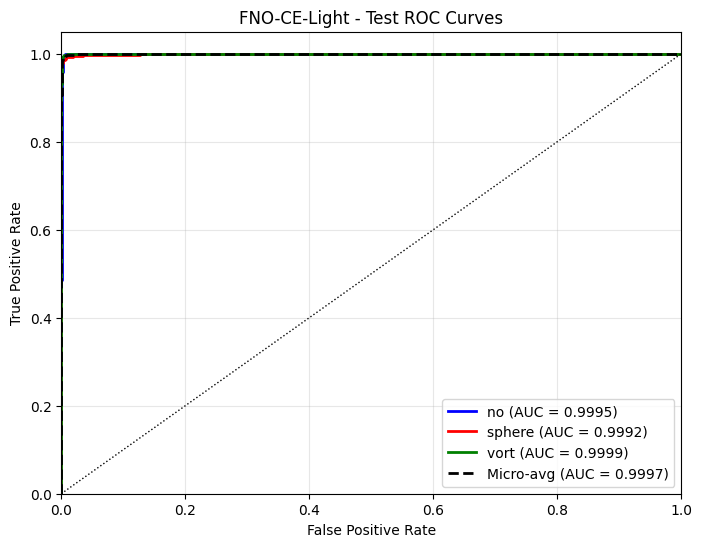


############################################################
# FNO-CE
############################################################

TRAIN Metrics
Overall Accuracy:  0.9871
Macro Precision:   0.9871
Macro Recall:      0.9871
Macro F1:          0.9870

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9808       0.9978       0.9892      
sphere          0.9891       0.9755       0.9823      
vort            0.9915       0.9879       0.9897      

Train AUC scores:
  Macro AUC: 0.9989
  Micro AUC: 0.9991
  Per-class:
    no: 0.9993
    sphere: 0.9982
    vort: 0.9993


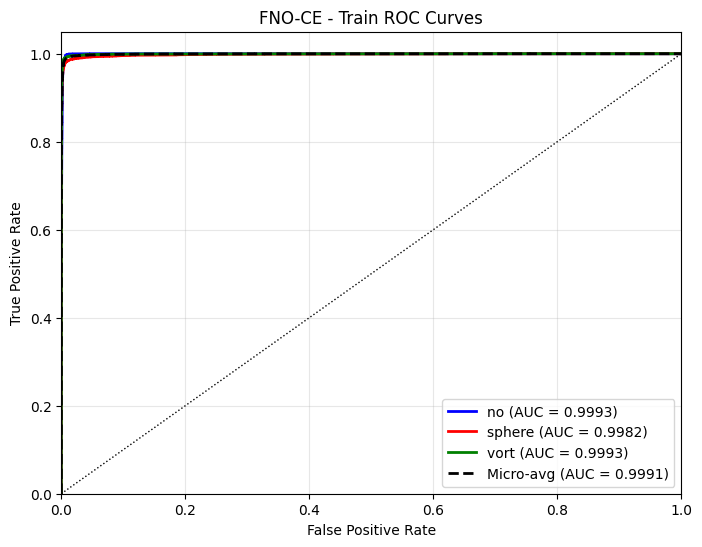


TEST Metrics
Overall Accuracy:  0.9850
Macro Precision:   0.9853
Macro Recall:      0.9853
Macro F1:          0.9852

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9739       0.9970       0.9853      
sphere          0.9885       0.9717       0.9800      
vort            0.9935       0.9871       0.9903      

Test AUC scores:
  Macro AUC: 0.9989
  Micro AUC: 0.9991
  Per-class:
    no: 0.9990
    sphere: 0.9980
    vort: 0.9997


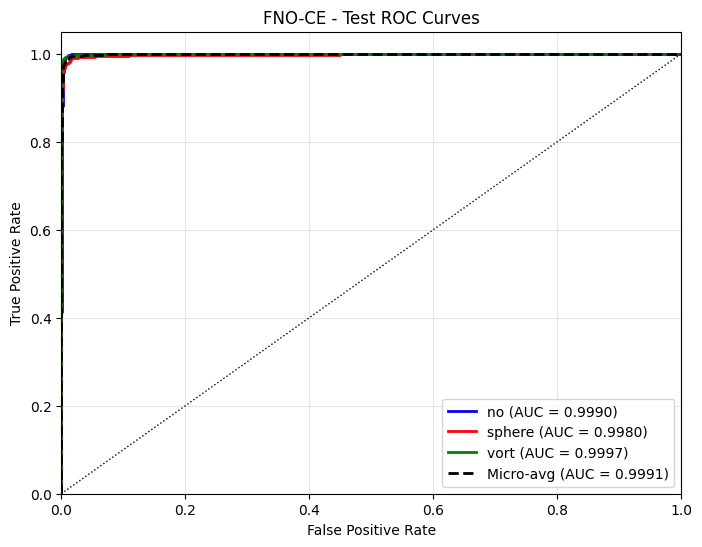


############################################################
# FNO-Hourglass
############################################################

TRAIN Metrics
Overall Accuracy:  0.9799
Macro Precision:   0.9800
Macro Recall:      0.9798
Macro F1:          0.9798

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9676       0.9935       0.9804      
sphere          0.9845       0.9600       0.9721      
vort            0.9880       0.9860       0.9870      

Train AUC scores:
  Macro AUC: 0.9984
  Micro AUC: 0.9987
  Per-class:
    no: 0.9987
    sphere: 0.9972
    vort: 0.9993


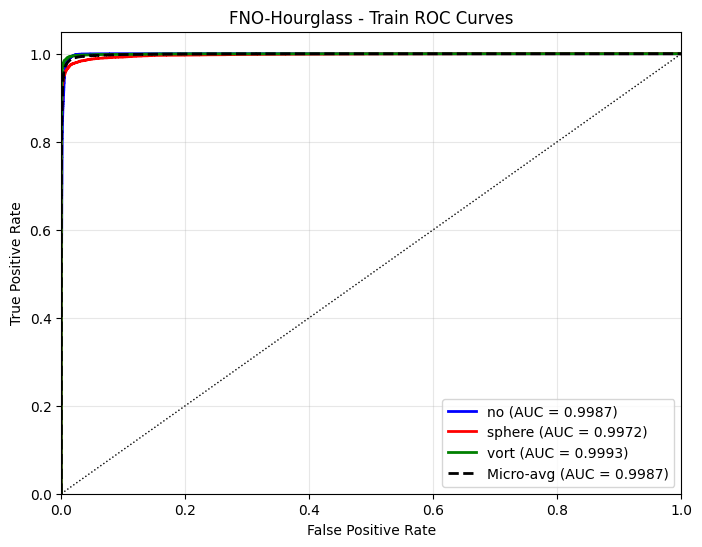


TEST Metrics
Overall Accuracy:  0.9817
Macro Precision:   0.9820
Macro Recall:      0.9822
Macro F1:          0.9820

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.9681       0.9941       0.9809      
sphere          0.9864       0.9622       0.9742      
vort            0.9914       0.9903       0.9909      

Test AUC scores:
  Macro AUC: 0.9986
  Micro AUC: 0.9989
  Per-class:
    no: 0.9985
    sphere: 0.9975
    vort: 0.9998


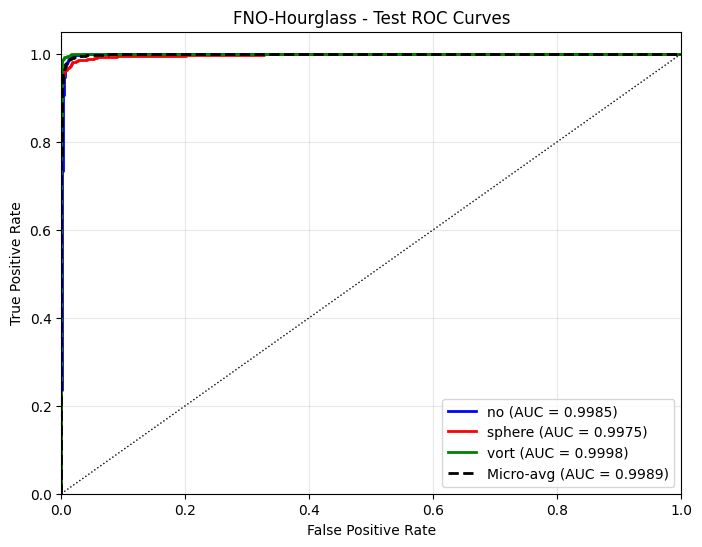


############################################################
# Naive-FNO
############################################################

TRAIN Metrics
Overall Accuracy:  0.7629
Macro Precision:   0.7565
Macro Recall:      0.7626
Macro F1:          0.7545

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.8078       0.9740       0.8831      
sphere          0.7125       0.5742       0.6359      
vort            0.7491       0.7396       0.7444      

Train AUC scores:
  Macro AUC: 0.9141
  Micro AUC: 0.9210
  Per-class:
    no: 0.9796
    sphere: 0.8555
    vort: 0.9071


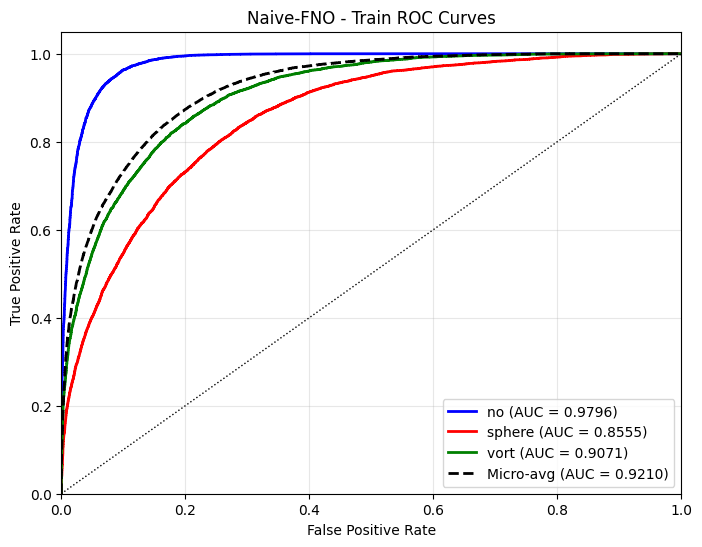


TEST Metrics
Overall Accuracy:  0.7643
Macro Precision:   0.7616
Macro Recall:      0.7675
Macro F1:          0.7563

Per-class metrics:
Class           Precision    Recall       F1          
---------------------------------------------------
no              0.7932       0.9772       0.8757      
sphere          0.7631       0.5656       0.6497      
vort            0.7284       0.7597       0.7437      

Test AUC scores:
  Macro AUC: 0.9173
  Micro AUC: 0.9201
  Per-class:
    no: 0.9787
    sphere: 0.8656
    vort: 0.9075


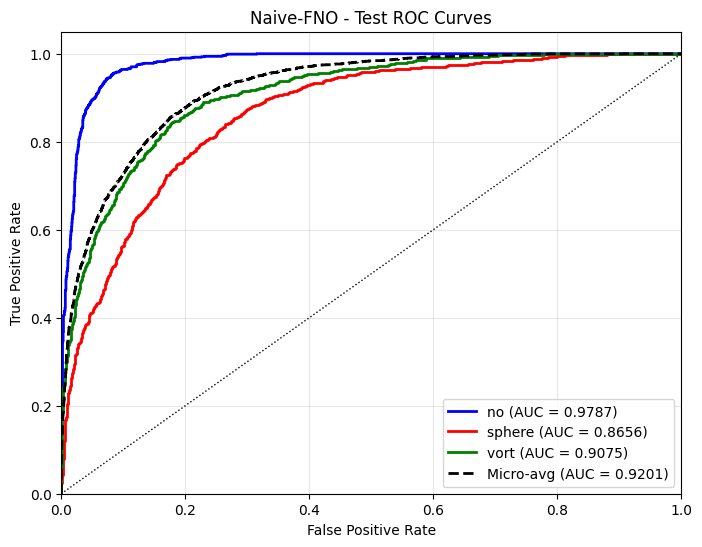

In [18]:
all_train_results={}
for model_name, model in models.items():
    print(f"\n{'#'*60}")
    print(f"# {model_name}")
    print(f"{'#'*60}")
    
    # Train evaluation
    train_loss, train_acc, train_preds, train_labels, train_probs = evaluate(model, train_eval_dataloader, criterion, device)
    all_train_results[model_name]= (train_loss, train_acc, train_preds, train_labels, train_probs)
    train_metrics = compute_metrics(train_preds, train_labels, class_names)
    print_metrics(train_metrics, "TRAIN", class_names)
    
    # ROC-AUC for train
    fpr, tpr, roc_auc = compute_roc_auc(train_labels, train_probs, class_names)
    print(f"\nTrain AUC scores:")
    print(f"  Macro AUC: {roc_auc['macro']:.4f}")
    print(f"  Micro AUC: {roc_auc['micro']:.4f}")
    print(f"  Per-class:")
    for i, cname in enumerate(class_names):
        print(f"    {cname}: {roc_auc[i]:.4f}")
    plot_roc_curves(fpr, tpr, roc_auc, class_names, title=f"{model_name} - Train ROC Curves")
    
    # Test evaluation
    test_loss, test_acc, test_preds, test_labels, test_probs = evaluate(model, test_dataloader, criterion, device)
    test_metrics = compute_metrics(test_preds, test_labels, class_names)
    print_metrics(test_metrics, "TEST", class_names)
    
    # ROC-AUC for test
    fpr, tpr, roc_auc = compute_roc_auc(test_labels, test_probs, class_names)
    print(f"\nTest AUC scores:")
    print(f"  Macro AUC: {roc_auc['macro']:.4f}")
    print(f"  Micro AUC: {roc_auc['micro']:.4f}")
    print(f"  Per-class:")
    for i, cname in enumerate(class_names):
        print(f"    {cname}: {roc_auc[i]:.4f}")
    plot_roc_curves(fpr, tpr, roc_auc, class_names, title=f"{model_name} - Test ROC Curves")

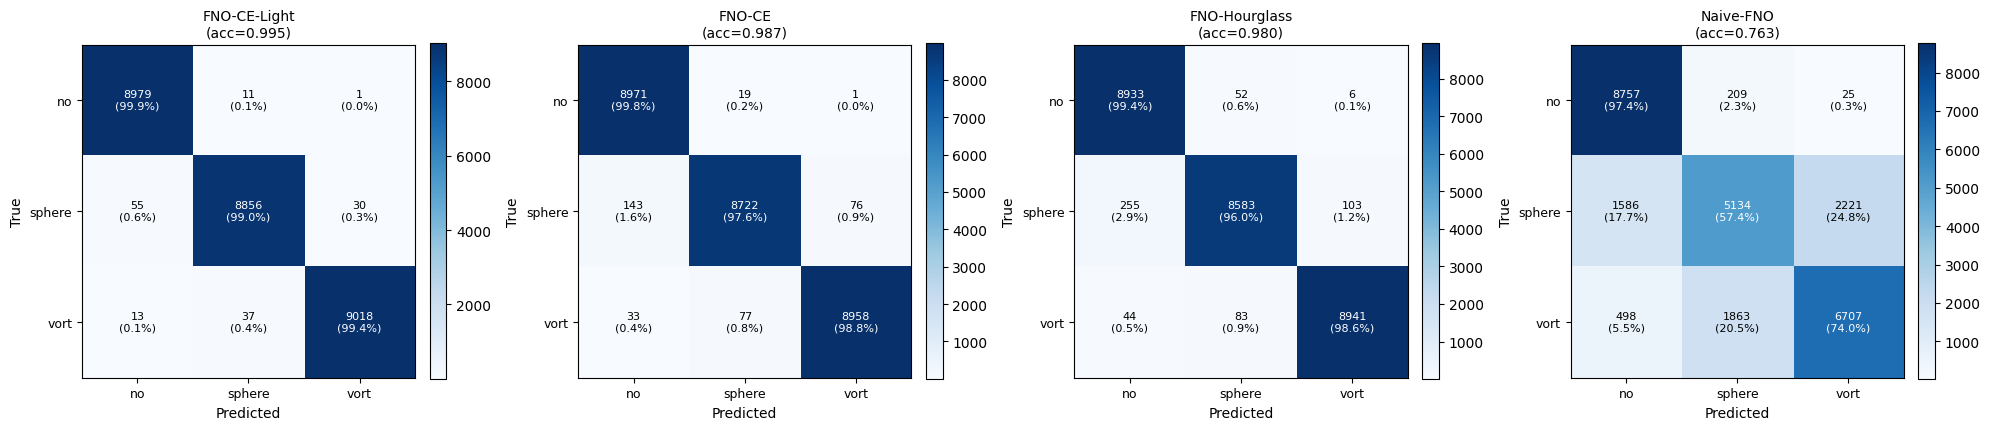

In [19]:
if all_train_results:
    plot_confusion_matrices(all_train_results, class_names)